Generating raw, messy asset metrics tracking dataset...

--- [Step 1] Ingested Dataset Structural Shape ---
Rows: 300 | Columns: 7

--- Identified Operational Data Field Structural Types ---
coaster_name              object
location                  object
material_type             object
speed_mph                float64
height_ft                float64
year_introduced            int64
unnecessary_id_column      int64
dtype: object

--- Descriptive Feature Statistics Summary ---
        speed_mph   height_ft  year_introduced  unnecessary_id_column
count  276.000000  285.000000       300.000000             300.000000
mean    55.864759  115.554832      2007.440000            5873.786667
std     15.839138   37.229006        10.539926            2619.459807
min     13.230465   23.154675      1990.000000            1016.000000
25%     45.695714   89.913868      1998.750000            3529.750000
50%     55.988687  112.187596      2008.000000            6184.000000
75%     66.484498  139.103

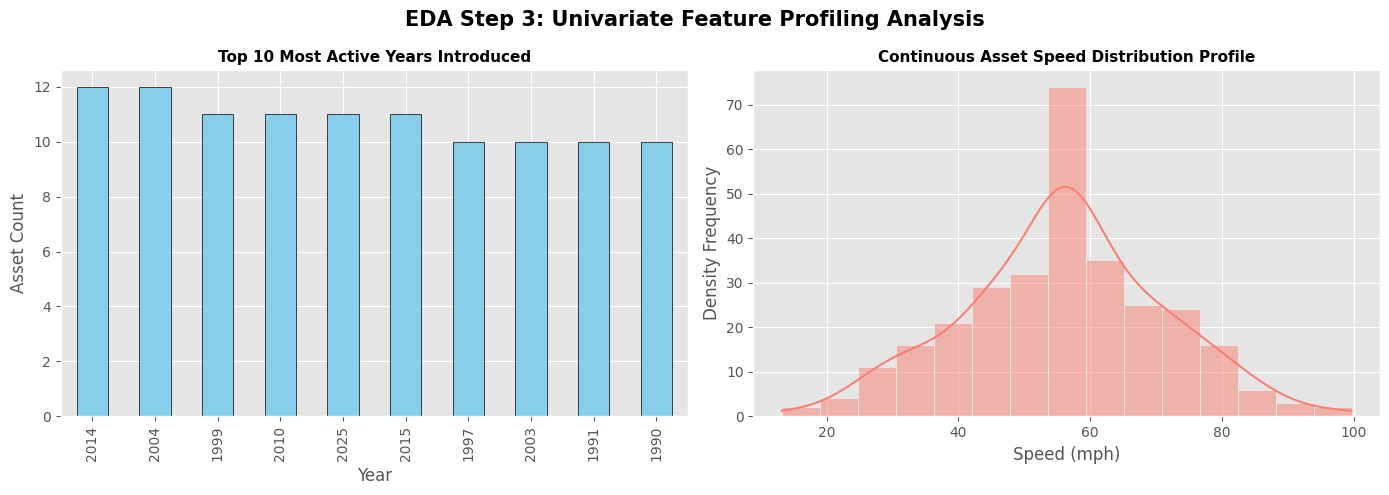


Processing multi-variable analytical data matrix relationships...


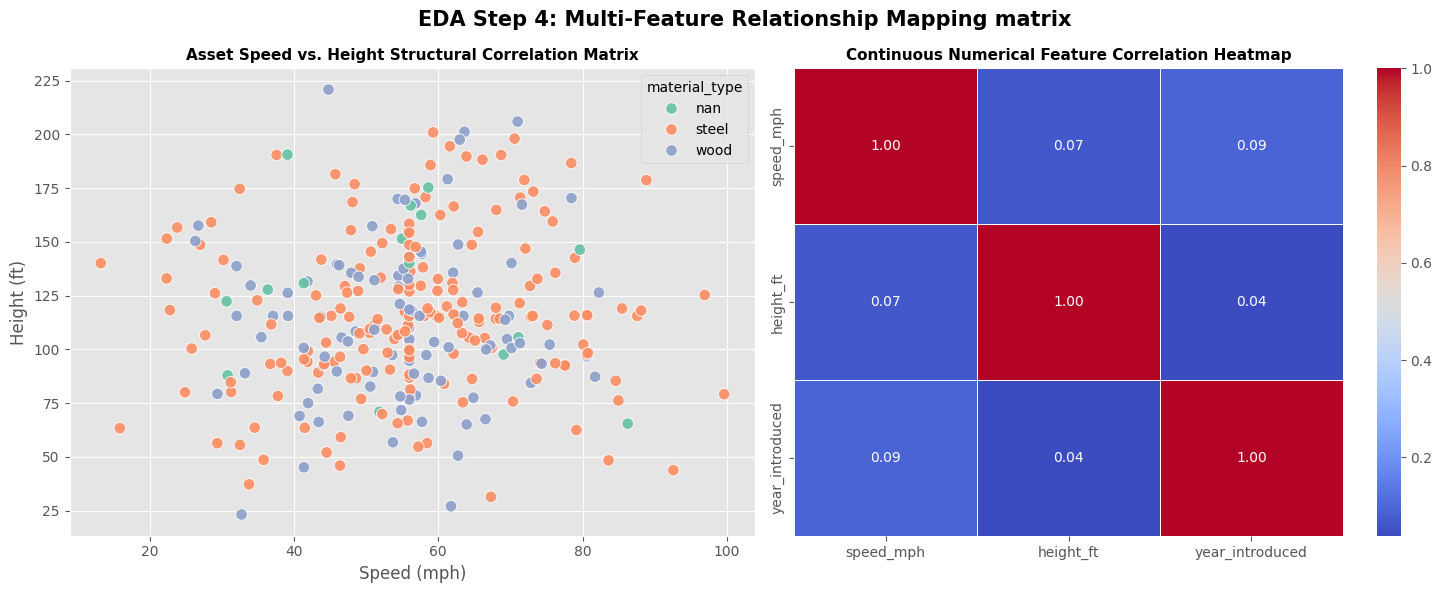


--- [Step 5] Addressing Target Performance Analytical Question ---
Question: What is the average coaster speed grouped across primary distinct regional locations?
                    mean  count
location                       
Busch Gardens  57.015848     63
Six Flags      56.094544     46
Cedar Point    55.820220     69
Other          55.703759     48
Kings Island   54.928092     74


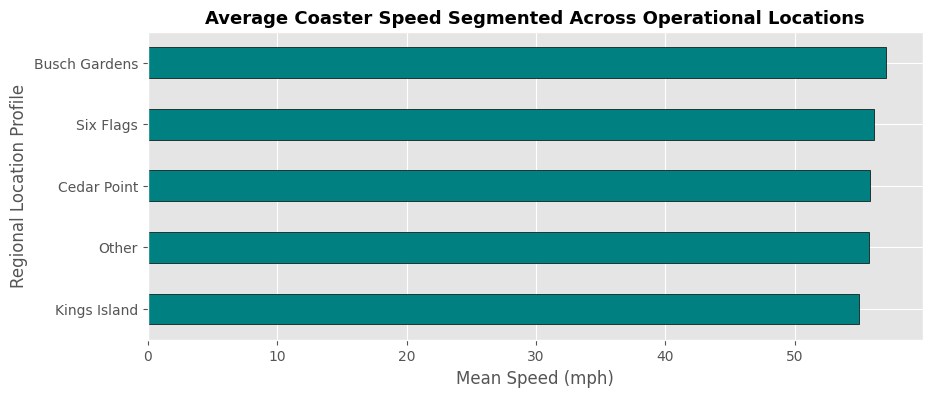

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure aesthetic style properties for plotting layers [01:47, 01:54]
plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)

# ==========================================
# PART 1: COMPREHENSIVE DATASET GENERATION
# ==========================================
print("Generating raw, messy asset metrics tracking dataset...")

np.random.seed(42)
records_count = 300

# Engineering messy structural features to mimic realistic data tasks [02:44, 05:34]
raw_data = {
    'coaster_name': [f'Coaster_{i}' for i in range(records_count)],
    'location': np.random.choice(['Cedar Point', 'Six Flags', 'Busch Gardens', 'Kings Island', 'Other '], size=records_count),
    'material_type': np.random.choice(['Steel', 'Wood', 'steel', 'wood', np.nan], size=records_count, p=[0.5, 0.3, 0.1, 0.05, 0.05]),
    'speed_mph': np.random.normal(loc=55, scale=15, size=records_count),
    'height_ft': np.random.normal(loc=110, scale=35, size=records_count),
    'year_introduced': np.random.randint(1990, 2026, size=records_count),
    'unnecessary_id_column': np.random.randint(1000, 9999, size=records_count)
}

# Injecting intentional structural tracking gaps (null values) [05:34]
df_raw = pd.DataFrame(raw_data)
df_raw.loc[np.random.choice(records_count, 25), 'speed_mph'] = np.nan
df_raw.loc[np.random.choice(records_count, 15), 'height_ft'] = np.nan

# ==========================================
# PART 2: EDA STEP 1 - DATA UNDERSTANDING
# ==========================================
print("\n--- [Step 1] Ingested Dataset Structural Shape ---") # [03:35]
print(f"Rows: {df_raw.shape[0]} | Columns: {df_raw.shape[1]}") # [03:43]

print("\n--- Identified Operational Data Field Structural Types ---") # [05:15]
print(df_raw.dtypes) # [05:24]

print("\n--- Descriptive Feature Statistics Summary ---") # [06:04]
print(df_raw.describe()) # [06:10]


# ==========================================
# PART 3: EDA STEP 2 - DATA PREPARATION
# ==========================================
print("\nExecuting data preparation and cleansing tasks...") # [06:40]

# 1. Feature Drop: Filter out column configurations not required for metrics analysis [06:47]
df_cleaned = df_raw.drop(columns=['unnecessary_id_column']).copy() # [09:55, 11:14]

# 2. Textual Value Normalization: Remove whitespace gaps & lower case text attributes [02:44]
df_cleaned['material_type'] = df_cleaned['material_type'].astype(str).str.strip().str.lower()
df_cleaned['location'] = df_cleaned['location'].astype(str).str.strip()

# 3. Missing Structural Values Identification & Treatment [14:38]
print("\nMissing items summary count per variable column:")
print(df_cleaned.isna().sum()) # [15:11]

# Fill empty numerical metrics safely using logical distribution midpoints
df_cleaned['speed_mph'] = df_cleaned['speed_mph'].fillna(df_cleaned['speed_mph'].median())
df_cleaned['height_ft'] = df_cleaned['height_ft'].fillna(df_cleaned['height_ft'].mean())

# 4. Identifying and Dropping Duplicate Observational Records [15:32]
duplicate_count = df_cleaned.duplicated(subset=['coaster_name', 'location']).sum()
print(f"\nIdentified duplicate primary asset items: {duplicate_count}") # [16:33]
if duplicate_count > 0:
    df_cleaned = df_cleaned.drop_duplicates(subset=['coaster_name', 'location']).reset_index(drop=True) # [18:28, 20:04]


# ==========================================
# PART 4: EDA STEP 3 - FEATURE UNDERSTANDING (UNIVARIATE)
# ==========================================
print("\nPlotting individual metric profiling distributions...") # [20:57]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA Step 3: Univariate Feature Profiling Analysis', fontsize=15, fontweight='bold')

# Plot A: Value Counts Bar Representation for Year Introduced [21:42, 22:30]
top_years = df_cleaned['year_introduced'].value_counts().head(10)
top_years.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black') # [22:55, 23:22]
axes[0].set_title('Top 10 Most Active Years Introduced', fontsize=11, fontweight='bold') # [23:40]
axes[0].set_xlabel('Year') # [24:02]
axes[0].set_ylabel('Asset Count') # [24:11]

# Plot B: Numerical Density Metric Profiling (Histogram with KDE Line overlay) [25:12, 26:51]
sns.histplot(df_cleaned['speed_mph'], bins=15, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Continuous Asset Speed Distribution Profile', fontsize=11, fontweight='bold') # [25:43]
axes[1].set_xlabel('Speed (mph)') # [25:58]
axes[1].set_ylabel('Density Frequency')

plt.tight_layout()
plt.show()


# ==========================================
# PART 5: EDA STEP 4 - FEATURE RELATIONSHIPS (BIVARIATE/MULTIVARIATE)
# ==========================================
print("\nProcessing multi-variable analytical data matrix relationships...") # [27:35]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('EDA Step 4: Multi-Feature Relationship Mapping matrix', fontsize=15, fontweight='bold')

# Plot C: Bivariate Scatter Clustering Profile tinted by Material Category [28:00, 29:27]
sns.scatterplot(data=df_cleaned, x='speed_mph', y='height_ft', hue='material_type',
                palette='Set2', alpha=0.9, s=70, ax=axes[0]) # [30:17, 30:30]
axes[0].set_title('Asset Speed vs. Height Structural Correlation Matrix', fontsize=11, fontweight='bold') # [28:39]
axes[0].set_xlabel('Speed (mph)')
axes[0].set_ylabel('Height (ft)')

# Plot D: Correlation Heatmap Matrix Evaluation [33:41, 34:35]
numeric_cols = ['speed_mph', 'height_ft', 'year_introduced']
correlation_matrix = df_cleaned[numeric_cols].corr() # [34:04]
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1]) # [35:05]
axes[1].set_title('Continuous Numerical Feature Correlation Heatmap', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


# ==========================================
# PART 6: EDA STEP 5 - BUSINESS QUESTION ANCHORING
# ==========================================
# Formulating an direct, target inquiry: Which location offers the highest performance metrics? [35:30, 36:03]
print("\n--- [Step 5] Addressing Target Performance Analytical Question ---")
print("Question: What is the average coaster speed grouped across primary distinct regional locations?")

# Group data and pull strategic aggregates [36:55, 37:29]
location_performance = df_cleaned.groupby('location')['speed_mph'].agg(['mean', 'count']).sort_values(by='mean', ascending=False) # [37:37, 38:07]
print(location_performance)

# Visualize aggregate performance question resolution metrics [38:37]
plt.figure(figsize=(10, 4))
location_performance['mean'].plot(kind='barh', color='teal', edgecolor='black') # [38:42]
plt.title('Average Coaster Speed Segmented Across Operational Locations', fontsize=13, fontweight='bold') # [38:51]
plt.xlabel('Mean Speed (mph)') # [39:07]
plt.ylabel('Regional Location Profile')
plt.gca().invert_yaxis()  # Put highest average metric values cleanly at the top view panel [39:21]
plt.show()